# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


In [ ]:
shape = (*trainX.shape[1:3], 1)
shape

(28, 28, 1)

## 1.3. Визуализируем часть данных из датасета

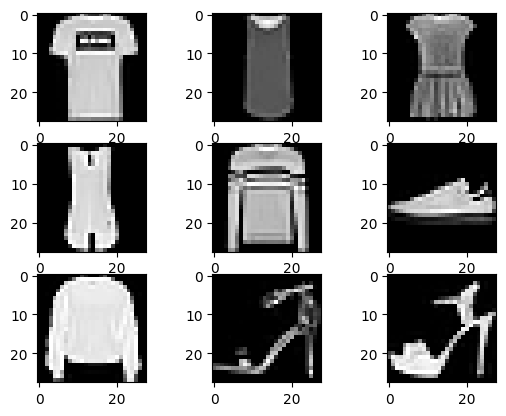

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
trainX = trainX.reshape((trainX.shape[0], 28, 28, 1)).astype("float32") / 255.0
testX = testX.reshape((testX.shape[0], 28, 28, 1)).astype("float32") / 255.0

print("trainX:", trainX.shape, trainX.dtype, trainX.min(), trainX.max())
print("testX:", testX.shape, testX.dtype, testX.min(), testX.max())

trainX: (60000, 28, 28, 1) float32 0.0 1.0
testX: (10000, 28, 28, 1) float32 0.0 1.0


In [ ]:
model_fashion = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=shape),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_fashion.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = Adam(learning_rate=0.001)

model_fashion.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 1.5. Обучаем модель

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

fashion_callbacks = [
    ModelCheckpoint(
        "best_fashion_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        mode="max",
        verbose=1
    )
]

history_fashion = model_fashion.fit(
    trainX,
    trainy,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=fashion_callbacks,
    verbose=1
)

Epoch 1/10
366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7282 - loss: 0.7796
Epoch 1: val_accuracy improved from -inf to 0.86483, saving model to best_fashion_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7305 - loss: 0.7728 - val_accuracy: 0.8648 - val_loss: 0.3837
Epoch 2/10
365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8766 - loss: 0.3432
Epoch 2: val_accuracy improved from 0.86483 to 0.87858, saving model to best_fashion_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8768 - loss: 0.3427 - val_accuracy: 0.8786 - val_loss: 0.3378
Epoch 3/10
363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8961 - loss: 0.2875
Epoch 3: val_accuracy improved from 0.87858 to 0.89792, saving model to best_fashion_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8962 - loss: 0.2873 - val_accuracy: 0.8979 - val_loss: 0.2851
Epoch 4/10
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9089 - loss: 0.2560
Epoch 4: val_accu

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

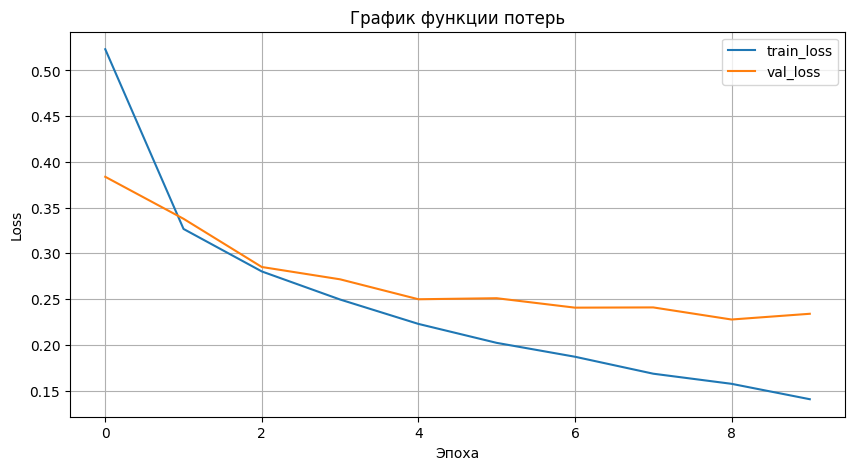

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_fashion.history['loss'], label='train_loss')
plt.plot(history_fashion.history['val_loss'], label='val_loss')
plt.title('График функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

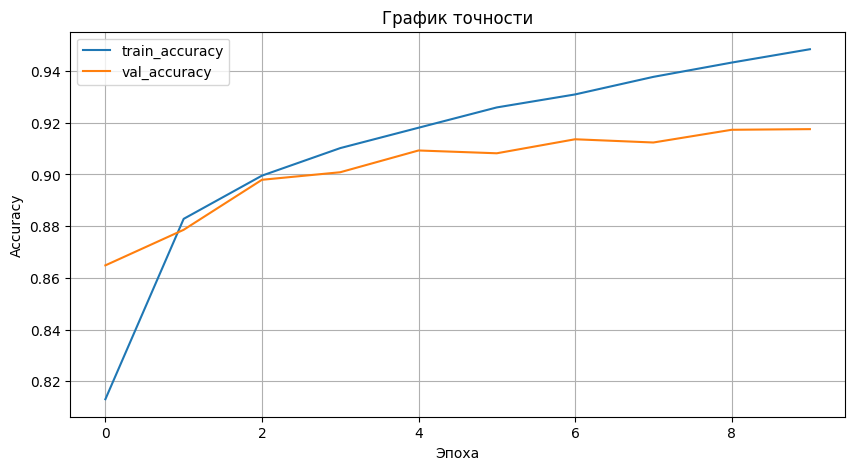

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_fashion.history['accuracy'], label='train_accuracy')
plt.plot(history_fashion.history['val_accuracy'], label='val_accuracy')
plt.title('График точности')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [ ]:
import cv2

def preprocess_fashion_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f"Не удалось открыть изображение: {image_path}")

    img_show = image.copy()

    image = cv2.resize(image, (28, 28))
    image = image.astype("float32") / 255.0

    if np.mean(image) > 0.5:
        image = 1.0 - image

    image = image.reshape(1, 28, 28, 1)
    return img_show, image

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [ ]:
from tensorflow.keras.models import load_model

best_fashion_model = load_model("best_fashion_model.keras")

Файл: tshirt.png
1. Shirt — 73.16%
2. T-shirt/top — 25.24%
3. Coat — 0.97%
----------------------------------------
Файл: trouser.png
1. Trouser — 99.96%
2. Coat — 0.02%
3. Shirt — 0.01%
----------------------------------------
Файл: pullover.png
1. Shirt — 49.12%
2. Pullover — 45.54%
3. Coat — 5.20%
----------------------------------------
Файл: dress.png
1. Dress — 99.89%
2. Bag — 0.09%
3. Shirt — 0.01%
----------------------------------------
Файл: sneaker.png
1. Sandal — 99.55%
2. Sneaker — 0.44%
3. Ankle boot — 0.01%
----------------------------------------


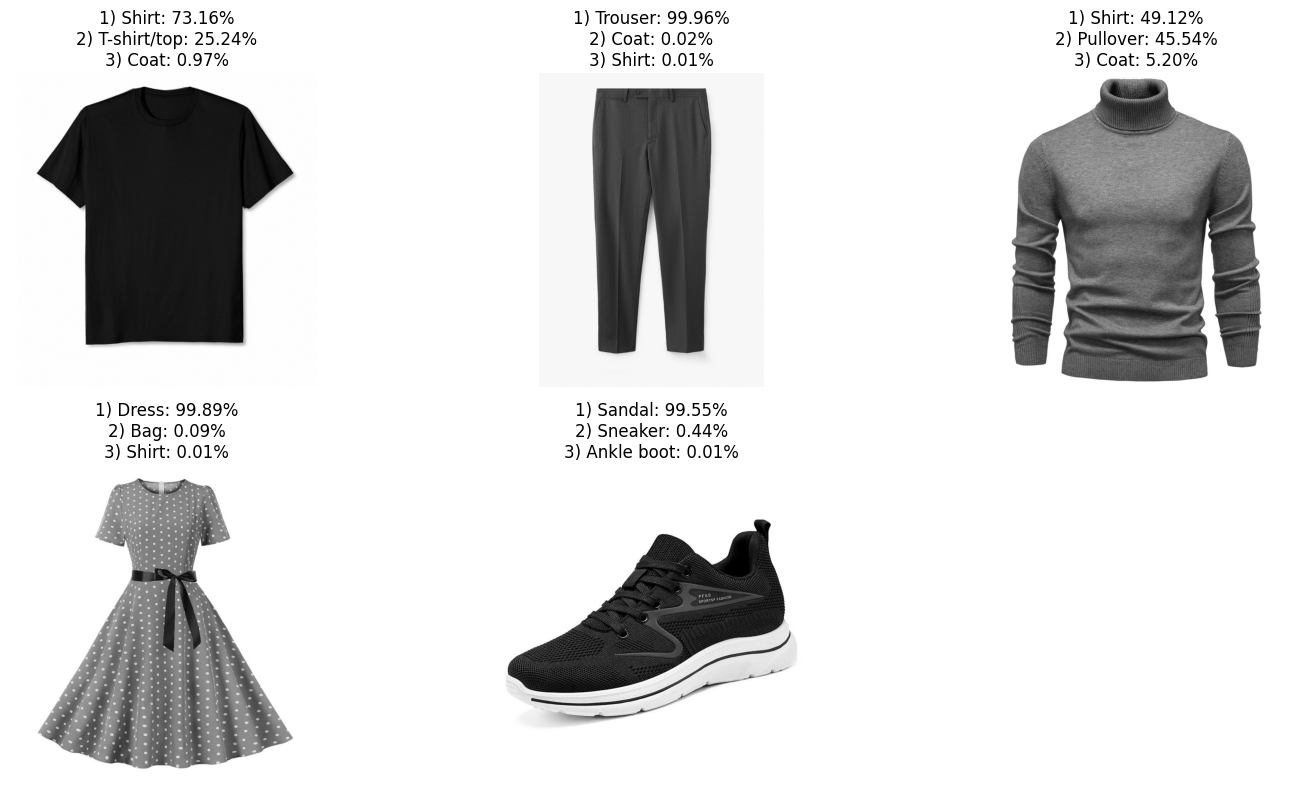

In [ ]:
image_paths = [
    "tshirt.png",
    "trouser.png",
    "pullover.png",
    "dress.png",
    "sneaker.png"
]

plt.figure(figsize=(15, 8))

for i, path in enumerate(image_paths, 1):
    img_show, img_model = preprocess_fashion_image(path)

    preds = best_fashion_model.predict(img_model, verbose=0)[0]
    top3_idx = np.argsort(preds)[-3:][::-1]

    plt.subplot(2, 3, i)
    plt.imshow(img_show, cmap='gray')
    plt.title(
        f"1) {class_names[top3_idx[0]]}: {preds[top3_idx[0]]*100:.2f}%\n"
        f"2) {class_names[top3_idx[1]]}: {preds[top3_idx[1]]*100:.2f}%\n"
        f"3) {class_names[top3_idx[2]]}: {preds[top3_idx[2]]*100:.2f}%"
    )
    plt.axis("off")

    print(f"Файл: {path}")
    for rank, idx in enumerate(top3_idx, 1):
        print(f"{rank}. {class_names[idx]} — {preds[idx]*100:.2f}%")
    print("-" * 40)

plt.tight_layout()
plt.show()

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from imutils import paths
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
! pip install wldhx.yadisk-direct
! curl -L $(yadisk-direct https://disk.yandex.ru/d/_ftl0nxR_CW-6Q) -o archive.zip
! unzip -qq archive.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6498k  100 6498k    0     0  1572k      0  0:00:04  0:00:04 --:--:-- 3057k
fresh_pomegranates_done/fresh_pomegranate_289 — копия.jpg:  mismatching "local" filename (fresh_pomegranates_done/fresh_pomegranate_289 тАФ ╨║╨╛╨┐╨╕╤П.jpg),
         continuing with "central" filename version
fresh_pomegranates_done/fresh_pomegranate_290 — копия.jpg:  mismatching "local" filename (fresh_pomegranates_done/fresh_pomegranate_290 тАФ ╨║╨╛╨┐╨╕╤П.jpg),
         continuing with "central" filename version
fresh_pomegranates_done/fresh_pomegranate_291 — копия.jpg:  mismatching "local" filename (fresh_pomegranates_done/fresh_pomegranate_291 тАФ ╨║╨╛╨┐╨╕╤П.jpg),
         continuing with "central" filename version
fresh_pomegranates_done/fresh_pomegranate_292 — копия.jpg

In [ ]:
imagePaths = sorted(list(paths.list_images("/content")))
random.shuffle(imagePaths)

def load_images_cnn(imagePaths, image_size=64):
    data = []
    labels = []

    for imagePath in imagePaths:
        image = cv2.imread(imagePath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (image_size, image_size))

        data.append(image)

        label = imagePath.split(os.path.sep)[-2]
        labels.append(label)

    return np.array(data), np.array(labels)

IMG_SIZE = 64
data, labels = load_images_cnn(imagePaths, image_size=IMG_SIZE)

print("Форма массива изображений:", data.shape)
print("Пример классов:", np.unique(labels))

Форма массива изображений: (755, 64, 64, 3)
Пример классов: ['content' 'fresh_peaches_done' 'fresh_pomegranates_done'
 'fresh_strawberries_done']


In [ ]:
data = data.astype("float32") / 255.0

lb = LabelBinarizer()
labels_bin = lb.fit_transform(labels)

X_train, X_val, Y_train, Y_val = train_test_split(
    data,
    labels_bin,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (604, 64, 64, 3)
X_val: (151, 64, 64, 3)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

fruits_callbacks = [
    ModelCheckpoint(
        "best_fruits_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max",
        verbose=1
    )
]

In [ ]:
model_fruits_cnn = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(len(lb.classes_), activation="softmax")
])

model_fruits_cnn.summary()

learning_rate = 0.001
epochs = 300
batch_size = 32

opt = Adam(learning_rate=learning_rate)

model_fruits_cnn.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_fruits_cnn = model_fruits_cnn.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,
    batch_size=32,
    callbacks=fruits_callbacks,
    verbose=1
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.4040 - loss: 1.1938
Epoch 1: val_accuracy improved from -inf to 0.56291, saving model to best_fruits_cnn.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 498ms/step - accuracy: 0.4060 - loss: 1.1897 - val_accuracy: 0.5629 - val_loss: 0.9479
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6507 - loss: 0.8099
Epoch 2: val_accuracy improved from 0.56291 to 0.74172, saving model to best_fruits_cnn.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6532 - loss: 0.8047 - val_accuracy: 0.7417 - val_loss: 0.6096
Epoch 3/15
16/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7796 - loss: 0.5538
Epoch 3: val_accuracy improved from 0.74172 to 0.75497, saving model to best_fruits_cnn.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7723 - loss: 0.5603 - val_accuracy: 0.7550 - val_loss: 0.5869
Epoch 4/15
16/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8068 - loss: 0.4619
Epoch 4: val_accuracy improved

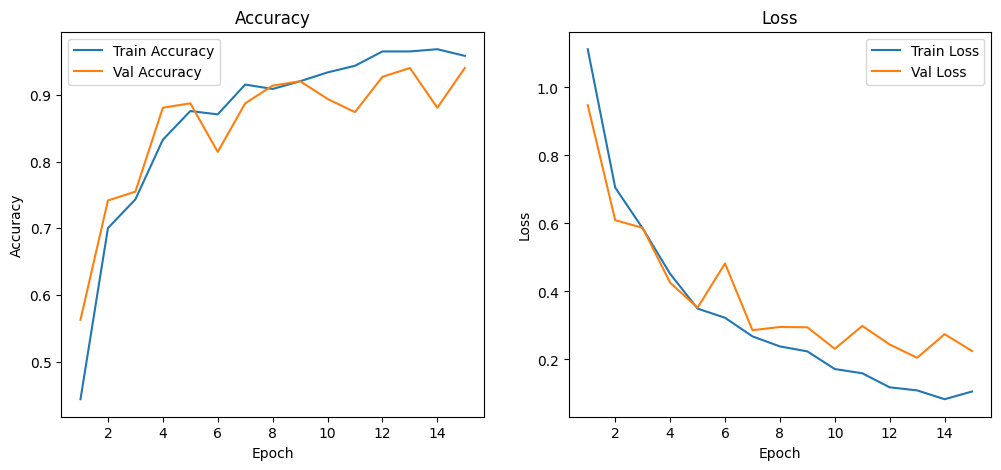

In [ ]:
acc = history_fruits_cnn.history["accuracy"]
val_acc = history_fruits_cnn.history["val_accuracy"]
loss = history_fruits_cnn.history["loss"]
val_loss = history_fruits_cnn.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.show()

## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [ ]:
from tensorflow.keras.layers import MaxPool2D

model_vgg16_like = Sequential([
    Conv2D(64, (3, 3), padding="same", activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(128, (3, 3), padding="same", activation="relu"),
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(256, (3, 3), padding="same", activation="relu"),
    Conv2D(256, (3, 3), padding="same", activation="relu"),
    Conv2D(256, (3, 3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(512, (3, 3), padding="same", activation="relu"),
    Conv2D(512, (3, 3), padding="same", activation="relu"),
    Conv2D(512, (3, 3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(512, (3, 3), padding="same", activation="relu"),
    Conv2D(512, (3, 3), padding="same", activation="relu"),
    Conv2D(512, (3, 3), padding="same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),

    Flatten(),
    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(len(lb.classes_), activation="softmax")
])

model_vgg16_like.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_vgg16_like.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,896,132 (60.64 MB)

 Trainable params: 15,896,132 (60.64 MB)

 Non-trainable params: 0 (0.00 B)

## 2.3. Сохраните полученные модели

In [ ]:
import pickle

model_fruits_cnn.save("model_fruits_cnn.keras")
model_vgg16_like.save("model_vgg16_like.keras")

with open("class_labels_current.pkl", "wb") as f:
    pickle.dump(lb, f)

print("Сохранены:")
print("- model_fruits_cnn.keras")
print("- model_vgg16_like.keras")
print("- class_labels_current.pkl")

Сохранены:
- model_fruits_cnn.keras
- model_vgg16_like.keras
- class_labels_current.pkl


## 2.4. Загрузите обученную модель из прошлой практической работы


In [ ]:
from tensorflow.keras.models import load_model
import pickle

# загрузка старой dense-модели
model_dense_old = load_model("image_classifier_model.keras")

# загрузка старых меток классов
with open("class_labels.pkl", "rb") as f:
    lb_old = pickle.load(f)

print("Старая модель загружена: image_classifier_model.keras")
print("Старые метки классов загружены: class_labels.pkl")

model_dense_old.summary()

Старая модель загружена: image_classifier_model.keras
Старые метки классов загружены: class_labels.pkl


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,835,019 (37.52 MB)

 Trainable params: 3,278,339 (12.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,556,680 (25.01 MB)


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [ ]:
indices = np.random.choice(len(X_val), size=15, replace=False)

X_compare = X_val[indices]
Y_compare = Y_val[indices]

true_idx = np.argmax(Y_compare, axis=1)
true_labels = lb.classes_[true_idx]

# 1. Простая CNN
pred_cnn_probs = model_fruits_cnn.predict(X_compare, verbose=0)
pred_cnn_idx = np.argmax(pred_cnn_probs, axis=1)
pred_cnn_labels = lb.classes_[pred_cnn_idx]

# 2. VGG-like CNN
pred_vgg_probs = model_vgg16_like.predict(X_compare, verbose=0)
pred_vgg_idx = np.argmax(pred_vgg_probs, axis=1)
pred_vgg_labels = lb.classes_[pred_vgg_idx]

# 3. Старая dense-модель
X_compare_dense_imgs = np.array([
    cv2.resize((img * 255).astype("uint8"), (32, 32)) for img in X_compare
]).astype("float32") / 255.0

X_compare_dense = X_compare_dense_imgs.reshape((X_compare_dense_imgs.shape[0], 32 * 32 * 3))

pred_dense_probs = model_dense_old.predict(X_compare_dense, verbose=0)
pred_dense_idx = np.argmax(pred_dense_probs, axis=1)
pred_dense_labels = lb_old.classes_[pred_dense_idx]

acc_cnn = accuracy_score(true_labels, pred_cnn_labels)
acc_vgg = accuracy_score(true_labels, pred_vgg_labels)
acc_dense = accuracy_score(true_labels, pred_dense_labels)

print(f"Точность простой CNN на 15 изображениях:   {acc_cnn:.4f}")
print(f"Точность VGG-like CNN на 15 изображениях: {acc_vgg:.4f}")
print(f"Точность dense-модели на 15 изображениях: {acc_dense:.4f}")

comparison_df = pd.DataFrame({
    "Истинный класс": true_labels,
    "Simple CNN": pred_cnn_labels,
    "VGG-like CNN": pred_vgg_labels,
    "Dense model": pred_dense_labels
})

display(comparison_df)

Точность простой CNN на 15 изображениях:   0.9333
Точность VGG-like CNN на 15 изображениях: 0.6000
Точность dense-модели на 15 изображениях: 0.1333


,Истинный класс,Simple CNN,VGG-like CNN,Dense model
0,fresh_strawberries_done,fresh_strawberries_done,fresh_strawberries_done,fresh_pomegranates_done
1,fresh_strawberries_done,fresh_strawberries_done,fresh_strawberries_done,fresh_pomegranates_done
2,fresh_strawberries_done,fresh_strawberries_done,fresh_strawberries_done,fresh_pomegranates_done
3,fresh_pomegranates_done,fresh_pomegranates_done,fresh_strawberries_done,fresh_pomegranates_done
4,fresh_peaches_done,fresh_peaches_done,fresh_peaches_done,fresh_pomegranates_done
5,fresh_strawberries_done,fresh_strawberries_done,fresh_strawberries_done,fresh_pomegranates_done
6,fresh_peaches_done,fresh_pomegranates_done,fresh_peaches_done,fresh_pomegranates_done
7,fresh_peaches_done,fresh_peaches_done,fresh_strawberries_done,fresh_pomegranates_done
8,fresh_peaches_done,fresh_peaches_done,fresh_strawberries_done,fresh_pomegranates_done
9,fresh_strawberries_done,fresh_strawberries_done,fresh_peaches_done,fresh_pomegranates_done


# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [ ]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

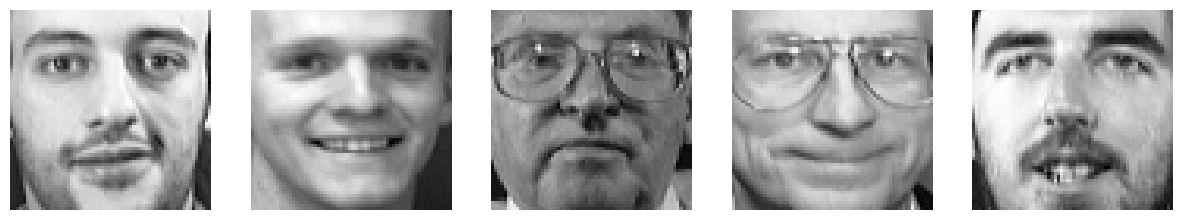

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [ ]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [ ]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

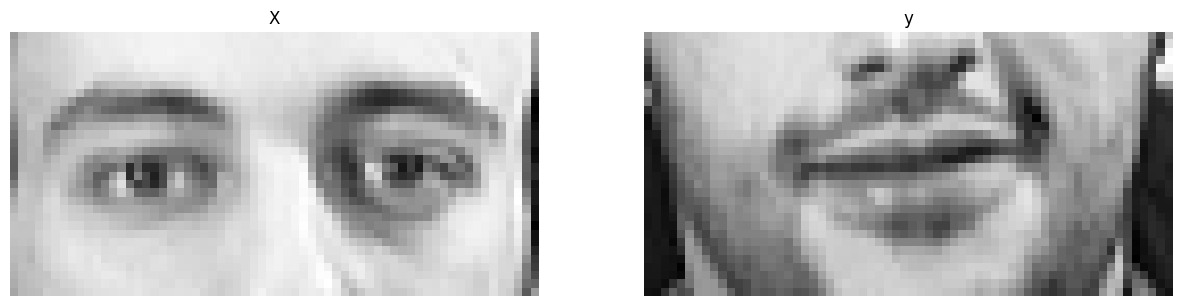

In [ ]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [ ]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

X_train_cnn = X_train.reshape((-1, 32, 64, 1))
X_test_cnn = X_test.reshape((-1, 32, 64, 1))

model_faces = Sequential([
    Input(shape=(32, 64, 1)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Flatten(),

    Dense(512, activation='relu'),
    Dense(32 * 64, activation='sigmoid')
])

model_faces.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2048)           │     1,050,624 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,532,416 (36.36 MB)

 Trainable params: 9,532,416 (36.36 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [ ]:
model_faces.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [ ]:
history_faces = model_faces.fit(
    X_train_cnn,
    y_train_n,
    epochs=17,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 7.2352e-04 - mae: 0.0199 - val_loss: 0.0102 - val_mae: 0.0742
Epoch 2/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - mae: 0.0278 - val_loss: 0.0105 - val_mae: 0.0753
Epoch 3/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - mae: 0.0328 - val_loss: 0.0106 - val_mae: 0.0764
Epoch 4/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - mae: 0.0355 - val_loss: 0.0103 - val_mae: 0.0744
Epoch 5/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0019 - mae: 0.0333 - val_loss: 0.0098 - val_mae: 0.0731
Epoch 6/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - mae: 0.0292 - val_loss: 0.0098 - val_mae: 0.0718
Epoch 7/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - mae: 0.0274 - val_loss: 0.0099 - val_mae: 0.0725
Epoch 8/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - mae: 0.0244 - val_loss: 0.0098 - val_mae: 0.0716
Epoch 9/17
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9

## 3.5. Сделайте предсказания на тестовых данных

In [ ]:
preds = model_faces.predict(X_test_cnn)
preds.shape

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


(80, 2048)

## 3.6. Посчитайте метрику качества на тестовых данных

In [ ]:
test_loss, test_mae = model_faces.evaluate(X_test_cnn, y_test_n, verbose=0)
print("Test loss:", test_loss)
print("Test MAE:", test_mae)

Test loss: 0.009462475776672363
Test MAE: 0.07017731666564941


In [ ]:
print(y_test_n.min(), y_test_n.max())
print(preds.min(), preds.max())
print(preds.shape, y_test_n.shape)

0.012396694 1.0
0.04212119 0.93015504
(80, 2048) (80, 2048)


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [ ]:
pred_test = preds.reshape((-1, 32, 64))
pred_test.shape

(80, 32, 64)

Отрисуйте все предсказания.

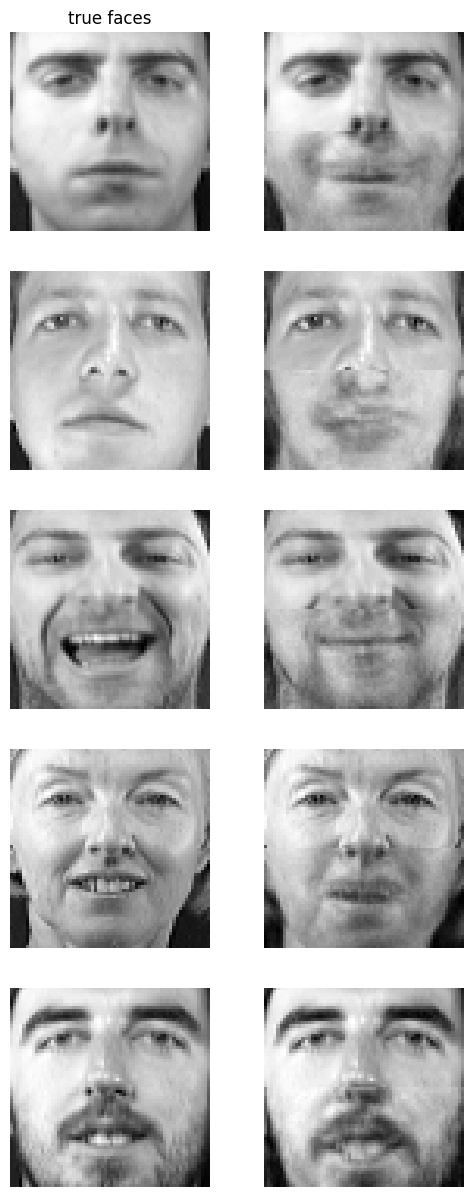

In [ ]:
# Пример кода:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

Saving Screenshot_5.png to Screenshot_5.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


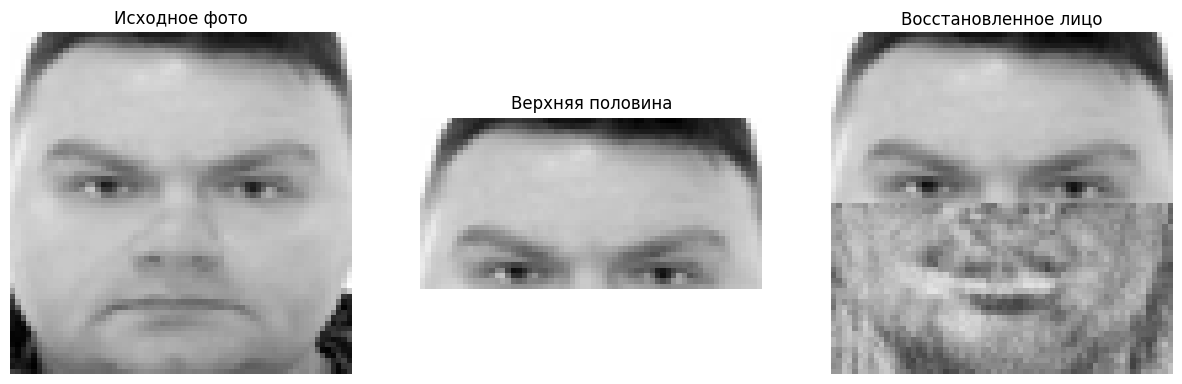

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert('L')
img = img.resize((64, 64))

img_array = np.array(img, dtype='float32') / 255.0

user_top = img_array[:32, :]

user_top_input = user_top.reshape((1, 32, 64, 1))

user_bottom_pred = model_faces.predict(user_top_input)
user_bottom_pred = user_bottom_pred.reshape((32, 64))

completed_face = np.vstack((user_top, user_bottom_pred))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_array, cmap='gray')
ax[0].set_title("Исходное фото")
ax[0].axis('off')

ax[1].imshow(user_top, cmap='gray')
ax[1].set_title("Верхняя половина")
ax[1].axis('off')

ax[2].imshow(completed_face, cmap='gray')
ax[2].set_title("Восстановленное лицо")
ax[2].axis('off')

plt.show()

Saving Screenshot_3.png to Screenshot_3 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


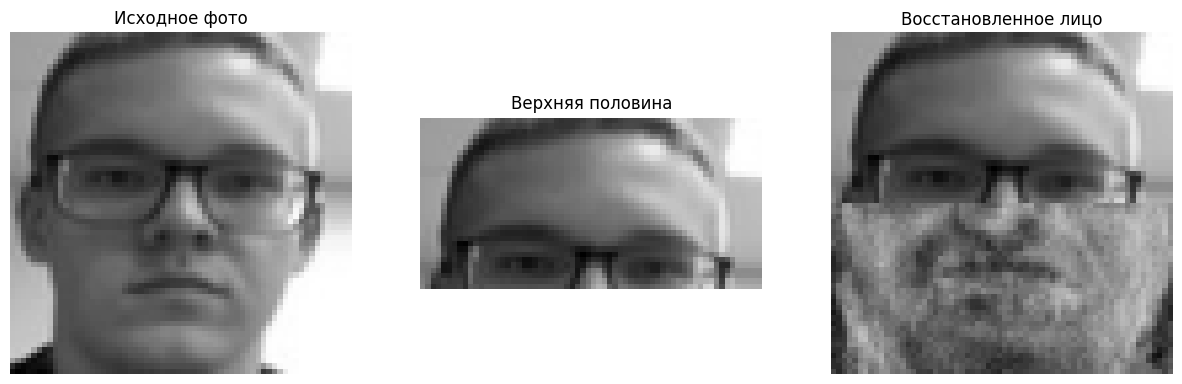

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert('L')
img = img.resize((64, 64))

img_array = np.array(img, dtype='float32') / 255.0

user_top = img_array[:32, :]

user_top_input = user_top.reshape((1, 32, 64, 1))

user_bottom_pred = model_faces.predict(user_top_input)
user_bottom_pred = user_bottom_pred.reshape((32, 64))

completed_face = np.vstack((user_top, user_bottom_pred))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_array, cmap='gray')
ax[0].set_title("Исходное фото")
ax[0].axis('off')

ax[1].imshow(user_top, cmap='gray')
ax[1].set_title("Верхняя половина")
ax[1].axis('off')

ax[2].imshow(completed_face, cmap='gray')
ax[2].set_title("Восстановленное лицо")
ax[2].axis('off')

plt.show()

Saving Screenshot_4.png to Screenshot_4 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


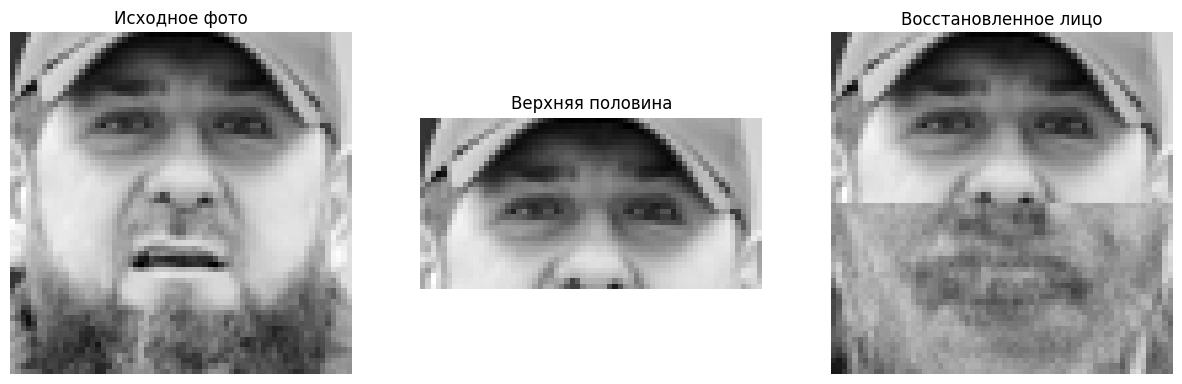

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert('L')
img = img.resize((64, 64))

img_array = np.array(img, dtype='float32') / 255.0

user_top = img_array[:32, :]

user_top_input = user_top.reshape((1, 32, 64, 1))

user_bottom_pred = model_faces.predict(user_top_input)
user_bottom_pred = user_bottom_pred.reshape((32, 64))

completed_face = np.vstack((user_top, user_bottom_pred))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_array, cmap='gray')
ax[0].set_title("Исходное фото")
ax[0].axis('off')

ax[1].imshow(user_top, cmap='gray')
ax[1].set_title("Верхняя половина")
ax[1].axis('off')

ax[2].imshow(completed_face, cmap='gray')
ax[2].set_title("Восстановленное лицо")
ax[2].axis('off')

plt.show()